In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
df_customers = pd.read_csv("/content/drive/MyDrive/olist_customers_dataset.csv")
df_order_payments = pd.read_csv("/content/drive/MyDrive/olist_order_payments_dataset.csv")
df_orders = pd.read_csv("/content/drive/MyDrive/olist_orders_dataset.csv")
df_order_reviews = pd.read_csv("/content/drive/MyDrive/olist_order_reviews_dataset.csv")
df_products = pd.read_csv("/content/drive/MyDrive/olist_products_dataset.csv")
df_geolocation = pd.read_csv("/content/drive/MyDrive/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("/content/drive/MyDrive/olist_order_items_dataset.csv")



In [47]:
datasets = {
    "df_customers": df_customers,
    "df_orders": df_orders,
    "df_order_items": df_order_items,
    "df_order_payments": df_order_payments,
    "df_order_reviews": df_order_reviews,
    "df_products": df_products

}

for name, df in datasets.items():
  print(name, df.shape)

df_customers (99441, 5)
df_orders (99441, 8)
df_order_items (112650, 7)
df_order_payments (103886, 5)
df_order_reviews (99224, 7)
df_products (32951, 9)


# Tabela pagamentos

In [48]:
df_order_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [49]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [50]:
df_order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [51]:
df_order_payments = df_order_payments.dropna()

In [52]:
df_order_payments = df_order_payments.drop_duplicates()

# Método de pagamento mais usado

In [53]:
df_metodo_pagamento_mais_usado = df_order_payments.payment_type.value_counts()
df_metodo_pagamento_mais_usado

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


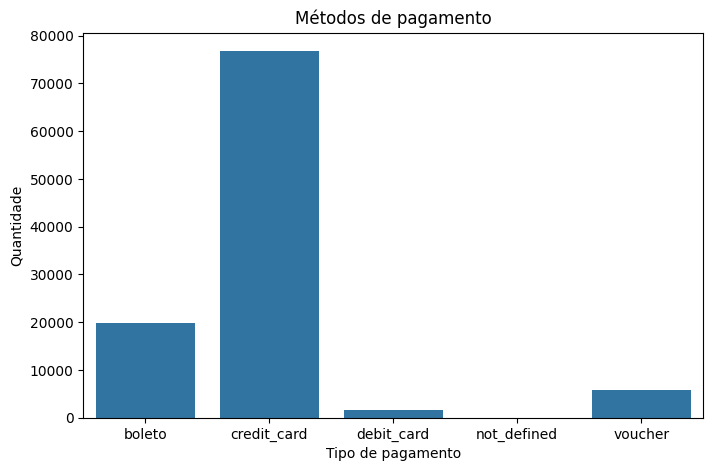

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_order_payments,
    x="payment_type",
    order=sorted(df_order_payments["payment_type"].unique())
)

plt.title("Métodos de pagamento")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Quantidade")

plt.show()

# Valor médio da compra de acordo com o meio de pagamento

In [55]:
df_valor_medio_compra = df_order_payments.groupby("payment_type")["payment_value"].mean()
df_valor_medio_compra

,payment_value
payment_type,
boleto,145.034435
credit_card,163.319021
debit_card,142.570170
not_defined,0.000000
voucher,65.703354


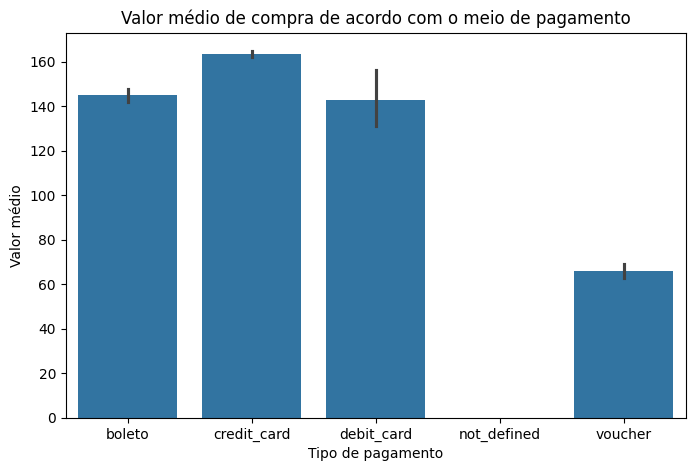

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_order_payments,
    x="payment_type",
    y="payment_value",
    order=sorted(df_order_payments["payment_type"].unique())
)

plt.title("Valor médio de compra de acordo com o meio de pagamento")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio")
plt.show()

# Tabela de pedidos

In [57]:

df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [58]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [59]:
df_copia = df_orders.copy()

Mudando o tipo de dado de object para datetime

In [60]:
coluna_datas = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

In [61]:
df_orders[coluna_datas] = df_orders[coluna_datas].apply(
    pd.to_datetime
)
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [62]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


# Lead time entre compra, aprovação, postagem e entrega

1.Tempo entre compra e aprovação: quanto tempo (em dias) o pagamento demora a ser aprovado.

In [64]:
lead_time_pagamento = (
    df_orders["order_approved_at"] - df_orders["order_purchase_timestamp"]
).dt.days
lead_time_pagamento

,0
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0
...,...
99436,0.0
99437,0.0
99438,0.0
99439,0.0


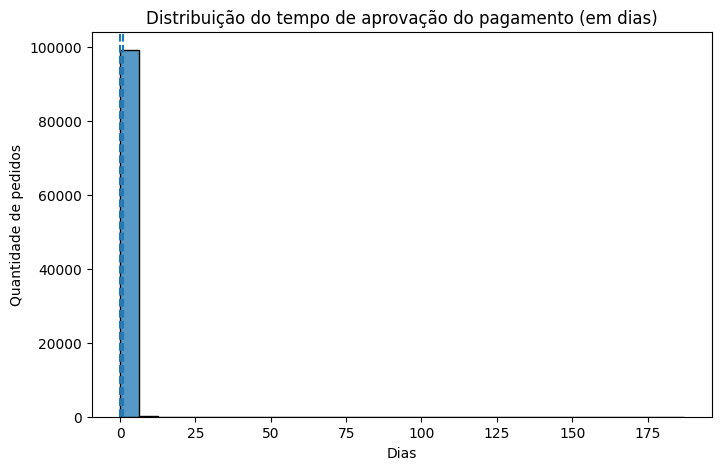

In [65]:
plt.figure(figsize=(8,5))

sns.histplot(lead_time_pagamento, bins=30)

plt.axvline(0, linestyle="--")
plt.axvline(1, linestyle="--")

plt.title("Distribuição do tempo de aprovação do pagamento (em dias)")
plt.xlabel("Dias")
plt.ylabel("Quantidade de pedidos")

plt.show()

In [66]:
percentual_mesmo_dia = (lead_time_pagamento == 0).mean() * 100

print(f"{percentual_mesmo_dia:.2f}% dos pagamentos são aprovados no mesmo dia")

82.32% dos pagamentos são aprovados no mesmo dia


2. Lead time de processamento do vendedor: quanto tempo o vendedor demora para despachar o produto.

In [67]:
lead_time_envio = (
    df_orders["order_delivered_carrier_date"] - df_orders["order_approved_at"]
).dt.days
lead_time_envio

,0
0,2.0
1,0.0
2,0.0
3,3.0
4,0.0
...,...
99436,1.0
99437,1.0
99438,1.0
99439,3.0


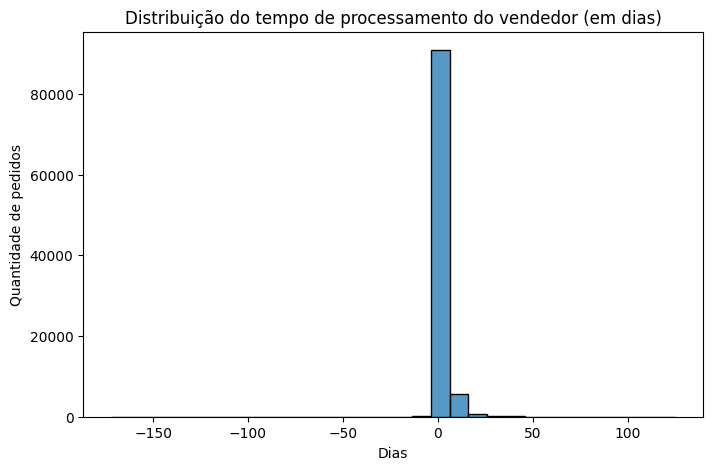

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(lead_time_envio, bins=30)

plt.title("Distribuição do tempo de processamento do vendedor (em dias)")
plt.xlabel("Dias")
plt.ylabel("Quantidade de pedidos")

plt.show()

In [69]:
media_dias_despacho_vendedor = (lead_time_envio).mean()
print(f'Os vendedores levam em méda {media_dias_despacho_vendedor:.2f} dias para despachar o produto.')

Os vendedores levam em méda 2.30 dias para despachar o produto.


3. Lead time de transporte: quanto tempo a transportadora leva para entregar.

In [70]:
lead_time_transporte = (
    df_orders["order_delivered_customer_date"] - df_orders["order_delivered_carrier_date"]
).dt.days
lead_time_transporte

,0
0,6.0
1,12.0
2,9.0
3,9.0
4,1.0
...,...
99436,7.0
99437,20.0
99438,23.0
99439,13.0


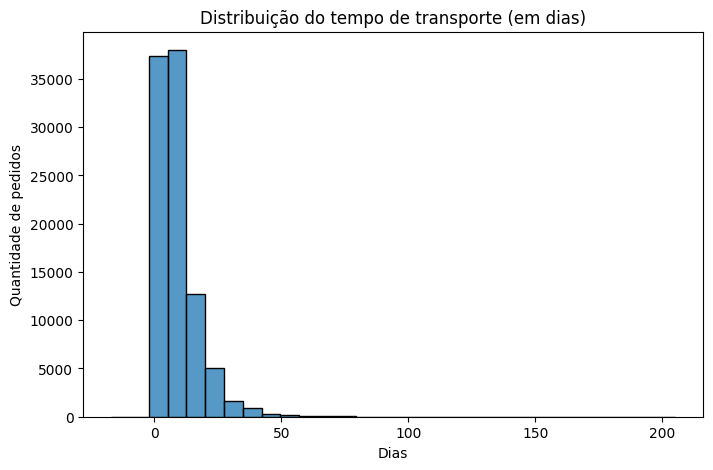

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(lead_time_transporte, bins=30)

plt.title("Distribuição do tempo de transporte (em dias)")
plt.xlabel("Dias")
plt.ylabel("Quantidade de pedidos")

plt.show()

In [72]:
media_dias_entrega_transportadora = (lead_time_transporte).mean()
print(f'O tempo médio de entrega é: {media_dias_entrega_transportadora:.2f} dias')

O tempo médio de entrega é: 8.88 dias


4. Lead time total do pedido: tempo total entre compra e entrega

In [73]:
df_lead_time_total = (
    df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]
).dt.days
df_lead_time_total

,0
0,8.0
1,13.0
2,9.0
3,13.0
4,2.0
...,...
99436,8.0
99437,22.0
99438,24.0
99439,17.0


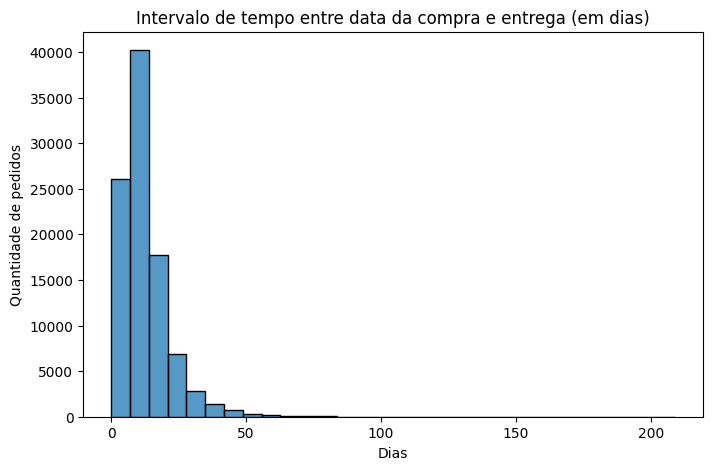

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(df_lead_time_total, bins=30)

plt.title("Intervalo de tempo entre data da compra e entrega (em dias)")
plt.xlabel("Dias")
plt.ylabel("Quantidade de pedidos")

plt.show()

In [75]:
media_tempo_total = (df_lead_time_total).mean()
print(f'O tempo médio total entre a data da compra e a entrega é: {media_tempo_total:.2f} dias')

O tempo médio total entre a data da compra e a entrega é: 12.09 dias


In [87]:
df_orders["atraso"] = np.where(
    df_orders["order_delivered_customer_date"] >
    df_orders["order_estimated_delivery_date"],
    "Sim",
    "Não"
  )


In [88]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,atraso
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Não
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Não
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Não
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,Não
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,Não
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,Não
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,Não
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,Não
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,Não


In [89]:
df_atrasos = df_orders.atraso.value_counts()
df_atrasos

,count
atraso,
Não,91614
Sim,7827


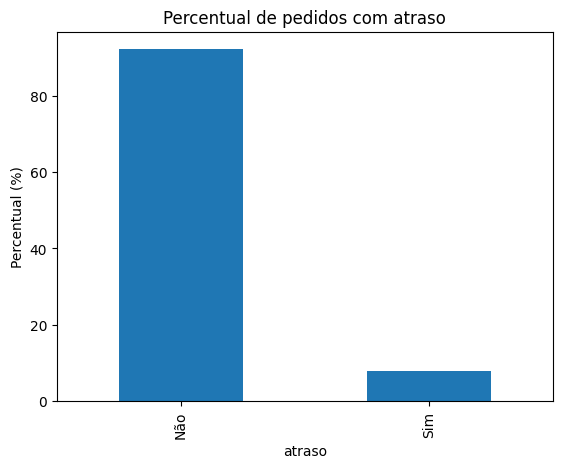

In [90]:
df_atrasos_pct = df_orders.atraso.value_counts(normalize=True) * 100
df_atrasos_pct.plot(kind="bar")

plt.title("Percentual de pedidos com atraso")
plt.ylabel("Percentual (%)")

plt.show()

# Tabela de avaliações

In [91]:
df_order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [92]:
df_copy2 = df_order_reviews.copy()

In [93]:
df_order_reviews = df_orders.merge(
    df_order_reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)
df_order_reviews


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,atraso,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,Não,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Não,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,Não,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,Não,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,Não,5.0
...,...,...,...,...,...,...,...,...,...,...
99987,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,Não,5.0
99988,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,Não,4.0
99989,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,Não,5.0
99990,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,Não,2.0


Correlação entre atrasos e review_score

In [94]:
df_order_reviews.groupby("atraso")["review_score"].mean()


,review_score
atraso,
Não,4.214307
Sim,2.566550


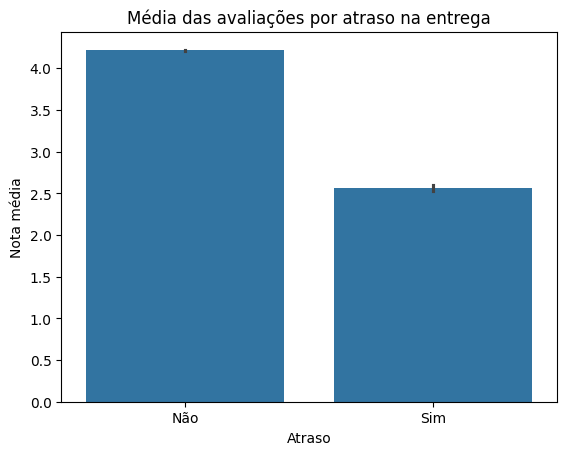

In [95]:
sns.barplot(
    data=df_order_reviews,
    x="atraso",
    y="review_score"
)

plt.title("Média das avaliações por atraso na entrega")
plt.xlabel("Atraso")
plt.ylabel("Nota média")

plt.show()